**Your Name:**

In [1]:
# getting things started
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

If you receive a warning on the above block, try to run it again and verify that everything is loaded properly.
___

## Understanding the dataset
We have used the titanic dataset before in class, however this dataset has been pruned to only include the social class, sex, age (as a nominal), and if the individual survived. The data can be stored in many ways, but is stored here as a table of values.

Data is located at: https://drive.google.com/drive/folders/1JfSZPPKGDdQ1LgZ8DR-CJeskgT35yt3d?usp=sharing

**Question 1**: Is this dataset a typical example of *transaction* data (*i.e.*, like the grocery store transaction data)? Why or Why not? What makes it similar or different?

**Hint**: think about the possible itemset lattice and how it might be different/similar. What makes an item in this dataset?

Enter your answer here:

This dataset is not typical of transaction data: typically, you would have a variable number of items per transaction (e.g., one customer buys t-shirts and socks, while another buys shaving cream and a cell phone charger). In this dataset, each "transaction" is a person with one value for each variable: class, sex, and age. These are characteristics, and the category is fixed across all observations, there are just different values. It would be like examining a dataset in which each customer bought t-shirts and socks, but of different colors. However, it it similar to typical transaction data in that associations can be made (e.g., "1st class is more likely to survive") by considering combinations of characteristics.

## Frequent Itemsets and Apriori
Run the following line of code to grab the R loaded data.frame and save it into a pandas dataframe.


Data is located at: https://drive.google.com/drive/folders/1JfSZPPKGDdQ1LgZ8DR-CJeskgT35yt3d?usp=sharing

In [3]:
# from google.colab import files
# uploaded = files.upload()

In [4]:
# getting things started
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

df_from_R = pd.read_csv('Rframe_as_pandas.csv')
df_from_R.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2201 entries, 0 to 2200
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  2201 non-null   int64 
 1   Class       2201 non-null   object
 2   Sex         2201 non-null   object
 3   Age         2201 non-null   object
 4   Survived    2201 non-null   object
dtypes: int64(1), object(4)
memory usage: 86.1+ KB


Text(0.5, 1.0, 'Support count for some 3-itemsets')

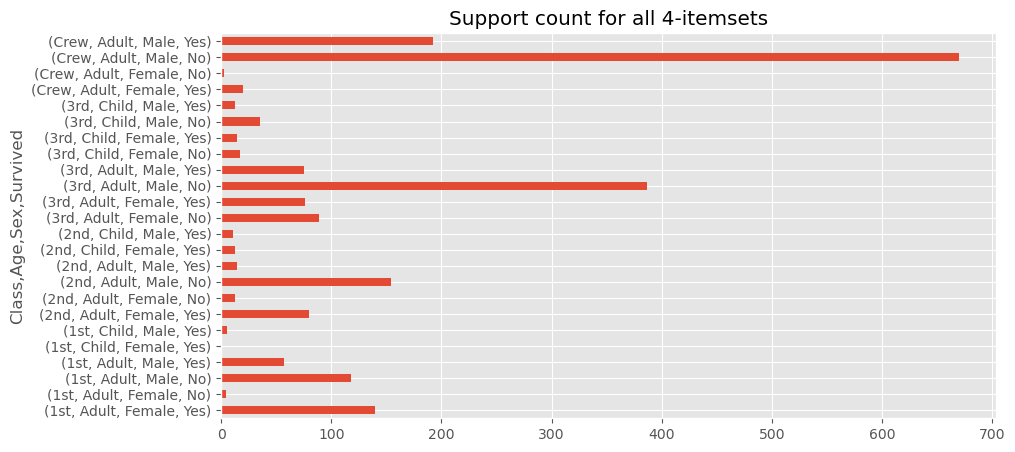

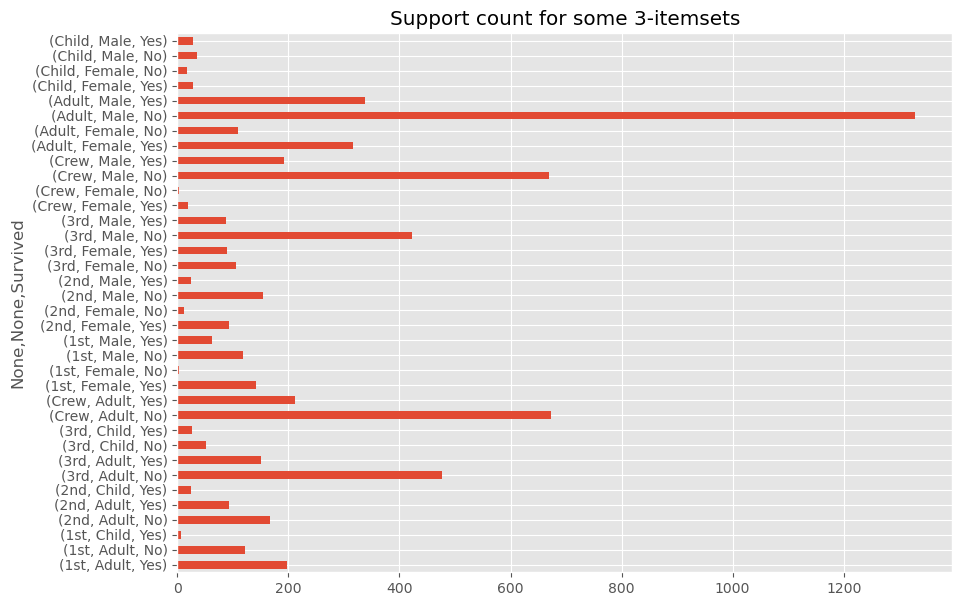

In [5]:
plt.style.use('ggplot')

# Now lets plot the number of times each itemset occurs graphically
# find counts of the four itemsets
f = plt.figure(figsize=(10,5))
df_grouped = df_from_R.groupby(by=['Class','Age','Sex'])
ax = df_grouped.Survived.value_counts().plot(kind='barh')
plt.title('Support count for all 4-itemsets')

# find all the three itemsets and concat them
f = plt.figure(figsize=(10,7))
df_grouped = df_from_R.groupby(by=['Class','Age'])
countsA = df_grouped.Survived.value_counts()
df_grouped = df_from_R.groupby(by=['Class','Sex'])
countsB = df_grouped.Survived.value_counts()
df_grouped = df_from_R.groupby(by=['Age','Sex'])
countsC = df_grouped.Survived.value_counts()

pd.concat((countsA,countsB,countsC)).plot(kind='barh')
plt.title('Support count for some 3-itemsets')

Use the graphs above to estimate the values for the following quantities. You do not need to calculate counts from the dataset, just try to get close by viewing from the graph. Recall that for a given rule, $X\rightarrow Y$, the confidence is given by
$$c=\frac{\sigma( X \cup Y)}{\sigma( X )} $$

**Questions 2**: Given the graphs above, what is the support count, $\sigma$, and support, $s$, for the itemset {1st, Adult, Yes}? What about the itemset {1st, Adult, Yes, Female}?

**Question 3**: What is the confidence, $c$, for the rule {1st, Adult, Yes} $\rightarrow$ {Female}?

----
Enter your answer to Questions 2 &3 here:

**Question 2**: 
* For {1st, Adult, Yes}, the support count ($\sigma$) is $\approx$ 200. The support ($s$) is 200 / 2201 ($s$ $\approx$ 9.1%)
* For {1st, Adult, Yes, Female}, the support count ($\sigma$) is $\approx$ 135. The support ($s$) is 135 / 2201 ($s$ $\approx$ 6.1%)

**Question 3**:
* Confidence $c$ for the rule {1st, Adult, Yes} $\rightarrow$ {Female} is 135/200 $\approx$ 67.5%.

In [ ]:
# Insert any calculations needed to answer the above question here

**Question 4**: What is the support count (an integer) for a *minsup* threshold of 0.25? Using the support count graphs above, which itemsets would be considered frequent with a *minsup* of 0.25? Are any of the 4-itemsets also maximal for this value of *minsup*? Why or Why not?

----
Enter your answer to Question 4 here:

* Support count for minsup 0.25 is 0.25 × 2201 (550.25)
* The following itemsets would be considered frequent at minsup 0.25: {Crew, Adult, Male, No} ($\approx$ 675), {Adult, Male, No} ($\approx$ 1325), {Crew, Male, No} ($\approx$ 625), and {Crew, Adult, No} ($\approx$ 625, this may be redundant to {Crew, Male, No}
* {Crew, Adult, Male, No} is maximal because there is no superset which includes it (in fact, tehre are no 5-item supersets)

In [ ]:
# Insert any calculations needed to answer the above question here

### Generating candidates
Assume that the 3-itemset bar graph above contains ALL the possible frequent 3-itemsets in the titanic dataset and their support count.

**Question 5**: If the minimum support count equals 200, then use the bar graph to select the 3-itemsets that are frequent. Use these itemsets and the apriori principle to generate candidate 4-itemsets that might be frequent. Please show your thought process.

**Question 5**

Frequent 3-itemsets at minsup count 200:

* {Adult, Male, Yes} ($\approx$ 350)
* {Adult, Male, No} ($\approx$ 1325)
* {Adult, Female, Yes} ($\approx$ 300)
* {Crew, Male, No} ($\approx$ 650)
* {3rd, Male, No} ($\approx$ 410)
* {Crew, Adult, Yes} ($\approx$ 210)
* {Crew, Adult, No} ($\approx$ 650)
* {3rd, Adult, No} ($\approx$ 475)
* {1st, Adult, Yes} ($\approx$ 200)

Candidate 4-item itemsets created by joining the 3-item datasets with common values

* {Crew, Adult, Male, No} - from {Crew, Male, No} + {Crew, Adult, No} or {Adult, Male, No} + {Crew, Male, No}
* {3rd, Adult, Male, No} - from {3rd, Male, No} + {3rd, Adult, No} or {Adult, Male, No} + {3rd, Male, No}
* {Crew, Adult, Male, Yes} - from {Crew, Adult, Yes} + {Adult, Male, Yes}
* {1st, Adult, Male, Yes} - from {1st, Adult, Yes} + {Adult, Male, Yes}
* {Crew, Adult, Female, Yes} - from {Crew, Adult, Yes} + {Adult, Female, Yes}
* {1st, Adult, Female, Yes} - from {1st, Adult, Yes} + {Adult, Female, Yes}

For each of the candidate itemsets, all possible 3-item itemsets must be present in the list of frequent itemsets:

* {Crew, Adult, Male, No} - out, {Crew, Adult, Male} not frequent
* {3rd, Adult, Male, No} - out, {3rd, Adult, Male} not frequent
* {Crew, Adult, Male, Yes} - out, {Crew, Male, Yes} not frequent
* {1st, Adult, Male, Yes} - out, {1st, Male, Yes} not frequent
* {Crew, Adult, Female, Yes} - out, {Crew, Female, Yes} not frequent
* {1st, Adult, Female, Yes} - out, {1st, Female, Yes} not frequent

None of the candidate 4-item itemsets are frequent by a priori principle.